In [40]:
import yfinance as yf 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [41]:
'''

EACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS

1) ACQUIRE THE DATA 

2) DEFINE THE STRATEGY 

3) TEST THE STRATEGY


'''

'\n\nEACH STRATEGY SHOULD FOLLOW THE FOLLOWING THREE STEPS\n\n1) ACQUIRE THE DATA \n\n2) DEFINE THE STRATEGY \n\n3) TEST THE STRATEGY\n\n\n'

In [42]:
'''
EXPONENTIAL MOVING AVERAGE FORMULA: (Current Price - Previous EMA) * Multiplier + Previous EMA
'''

'\nEXPONENTIAL MOVING AVERAGE FORMULA: (Current Price - Previous EMA) * Multiplier + Previous EMA\n'

In [43]:
TICKER = "SPY"
LOOKBACK = 500
WINDOW = 10
MULTIPLIER = 2 / (WINDOW + 1)

In [44]:
def load_dataset(symbol):
    df = yf.download(TICKER, period="max")
    df.columns = df.columns.get_level_values(0)
    return pd.DataFrame(df)

In [45]:
df = load_dataset(TICKER)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
1993-01-29,24.175388,24.192583,24.072222,24.192583,1003200
1993-02-01,24.347328,24.347328,24.192578,24.192578,480500
1993-02-02,24.398916,24.416111,24.278555,24.330138,201300
1993-02-03,24.656822,24.674017,24.416100,24.433295,529400
1993-02-04,24.760000,24.811584,24.467695,24.742806,531500
...,...,...,...,...,...
2026-05-11,739.299988,740.789978,736.450012,736.450012,44024000
2026-05-12,738.179993,738.840027,731.830017,736.890015,54185300
2026-05-13,742.309998,743.909973,735.469971,738.469971,44200200


In [46]:
# calculate the ema using the sma
def exponential_moving_average(df):
    try:
        df["SMA"] = df["Close"].rolling(window=WINDOW).mean()
        df["EMA"] = df["SMA"].ewm(span=WINDOW, adjust=False).mean()
    except Exception as e:
        print(f"error: {e}")
    return df.dropna()

In [47]:
df = exponential_moving_average(df)
df

Price,Close,High,Low,Open,Volume,SMA,EMA
Date,,,,,,,
1993-02-11,24.725605,24.828772,24.639633,24.639633,19500,24.572576,24.572576
1993-02-12,24.536467,24.691217,24.536467,24.691217,42500,24.608683,24.579141
1993-02-16,23.917465,24.467687,23.883076,24.467687,374800,24.565697,24.576696
1993-02-17,23.900263,23.951846,23.814291,23.917457,210900,24.515832,24.565630
1993-02-18,23.883072,24.175377,23.556378,24.175377,378100,24.438457,24.542508
...,...,...,...,...,...,...,...
2026-05-11,739.299988,740.789978,736.450012,736.450012,44024000,724.669006,714.675589
2026-05-12,738.179993,738.840027,731.830017,736.890015,54185300,727.318005,716.974210
2026-05-13,742.309998,743.909973,735.469971,738.469971,44200200,730.391003,719.413627


In [48]:
# plot the asset against the exponential moving average
def plot_exponential_moving_average(df):
    df = df.iloc[-LOOKBACK:, :]
    plt.plot(df["Close"], label="SPY Closing Price")
    plt.plot(df["EMA"], label="Exponential Moving Average")
    plt.title("SPY Close Price vs EMA")
    plt.xlabel("Date")
    plt.ylabel("Closing Price $")
    plt.grid(True)
    plt.legend(loc=2)
    plt.show()

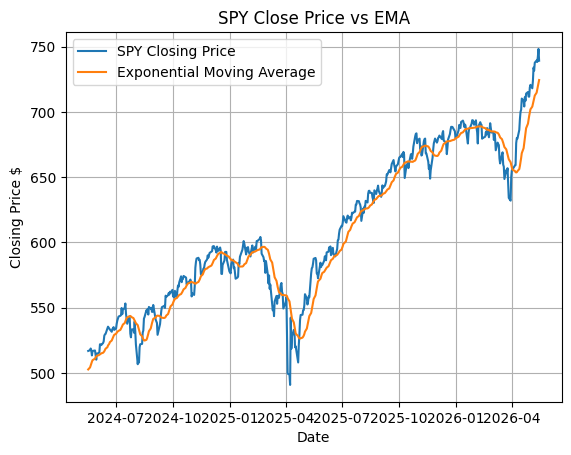

In [49]:
plot_exponential_moving_average(df)

In [50]:
'''

DEFINE STRATEGY:

BUY: PRICE > EMA

SELL: PRICE < EMA

'''

'\n\nDEFINE STRATEGY:\n\nBUY: PRICE > EMA\n\nSELL: PRICE < EMA\n\n'

In [51]:
def strategy(df):
    df["Strategy"] = np.where(df["Close"] > df["EMA"], 1, -1)
    df["Strategy"] = df["Strategy"].shift(1)
    return df.dropna()

In [52]:
df = strategy(df)
df

/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_2273/825530408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Strategy"] = np.where(df["Close"] > df["EMA"], 1, -1)
/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_2273/825530408.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Strategy"] = df["Strategy"].shift(1)


Price,Close,High,Low,Open,Volume,SMA,EMA,Strategy
Date,,,,,,,,
1993-02-12,24.536467,24.691217,24.536467,24.691217,42500,24.608683,24.579141,1.0
1993-02-16,23.917465,24.467687,23.883076,24.467687,374800,24.565697,24.576696,-1.0
1993-02-17,23.900263,23.951846,23.814291,23.917457,210900,24.515832,24.565630,-1.0
1993-02-18,23.883072,24.175377,23.556378,24.175377,378100,24.438457,24.542508,-1.0
1993-02-19,23.969053,23.969053,23.848692,23.883081,34900,24.359362,24.509208,-1.0
...,...,...,...,...,...,...,...,...
2026-05-11,739.299988,740.789978,736.450012,736.450012,44024000,724.669006,714.675589,1.0
2026-05-12,738.179993,738.840027,731.830017,736.890015,54185300,727.318005,716.974210,1.0
2026-05-13,742.309998,743.909973,735.469971,738.469971,44200200,730.391003,719.413627,1.0


In [53]:
def strategy_cumulative_returns(df):
    df["Asset Returns"] = (1 + df["Close"].pct_change()).cumprod() - 1
    df["Strategy Returns"] = (1 + df["Close"].pct_change() * df["Strategy"]).cumprod() - 1

    plt.plot(df["Asset Returns"], label=f"{TICKER} Returns")
    plt.plot(df["Strategy Returns"], label="EMA Strategy Returns")
    
    plt.grid(True)
    plt.legend(loc=2)
    plt.show()

/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_2273/491220401.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Asset Returns"] = (1 + df["Close"].pct_change()).cumprod() - 1
/var/folders/29/cmxsjz7x3p7ct1mhjll72pjh0000gn/T/ipykernel_2273/491220401.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Strategy Returns"] = (1 + df["Close"].pct_change() * df["Strategy"]).cumprod() - 1


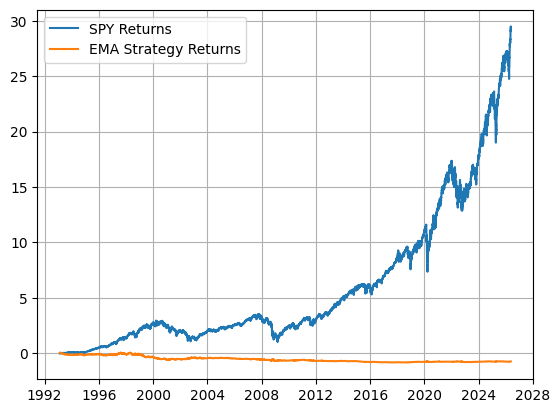

In [54]:
strategy_cumulative_returns(df)